# Bearing anomaly detection — DCASE-style (U-Net on mel spectrograms)

This notebook trains an **unsupervised** anomaly detector on **normal-only** bearing audio from `eval_data_bearing_train.zip`, scores **unlabeled** clips from `eval_data_bearing_test.zip`, and (optionally) measures **AUC / pAUC** on labeled **development** test audio from `dev_bearing.zip` (cross-section generalization: train sections 03–05, test sections 00–02).

**Always run section 0 first** (installs dependencies and sets `PROJECT_ROOT`). On **Google Colab**, enable **GPU** (`Runtime → Change runtime type`) before running.

Code lives in the `bearing_asd/` package (see README for the file list to upload).

## 0. Environment bootstrap (Google Colab + local)

- Uncomment `os.chdir(...)` if Colab’s working directory is not the project folder (the directory that contains this notebook, `bearing_asd/`, `requirements.txt`, and the zip archives).
- Installs `requirements.txt` via `pip` (does not reinstall PyTorch on Colab unless your `requirements.txt` pins it — keep the default file so Colab’s CUDA build stays).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys
import subprocess
from pathlib import Path

# --- Google Colab: uncomment if cwd is not your project root ---
os.chdir("/content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound")

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

req = PROJECT_ROOT / "requirements.txt"
if req.is_file():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req)], check=False)
else:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "librosa",
            "soundfile",
            "numpy",
            "pandas",
            "matplotlib",
            "scikit-learn",
            "tqdm",
            "torchinfo",
        ],
        check=False,
    )

import torch

print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(), end="")
if torch.cuda.is_available():
    print(f" | {torch.cuda.get_device_name(0)}")
else:
    print()

try:
    from IPython import get_ipython

    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("PROJECT_ROOT =", PROJECT_ROOT)

torch: 2.10.0+cu128 | CUDA: True | Tesla T4
PROJECT_ROOT = /content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound


## 1. Dataset and problem (summary)

See `bearing_asd/data_description.py` for the full narrative.

In [3]:
from IPython.display import Markdown, display

from bearing_asd import data_description

display(Markdown(data_description.get_dataset_overview_markdown()))

## What this data is

The archives follow **DCASE 2022 Challenge Task 2**: *Unsupervised Anomalous Sound Detection for Machine
Condition Monitoring with Domain Generalization* ([task overview](https://dcase.community/challenge2022/task-unsupervised-anomalous-sound-detection-for-machine-condition-monitoring#dataset-overview)).

- **Modality**: single-channel **audio**, **10 seconds** per clip, recorded in noisy factory-like conditions.
- **Machine focus here**: **bearing** sounds (one of seven machine types in the full benchmark).
- **Sections**: the **evaluation** track uses **sections 03–05** (different domain-shift scenarios than the
  **development** sections 00–02).

### `eval_data_bearing_train.zip`

- `bearing/train/`: **normal-only** clips for training (`section_03_*`, `section_04_*`, `section_05_*`).
- `bearing/attributes_0{3,4,5}.csv`: domain-shift parameters for **training** clips (e.g. velocity, mic
  location, factory noise mix), aligned with filenames.

### `eval_data_bearing_test.zip`

- `bearing/test/`: **unlabeled** test clips (`section_03_*.wav`, …). **No** normal/anomaly flag and **no**
  domain label — this matches the challenge **evaluation** setting.

### Optional `dev_bearing.zip` (recommended for *labeled* metrics)

- **Development** bearing data: **labeled** `test/` clips for sections **00–02** (`*_normal_*` / `*_anomaly_*`).
- Use this as a **separate generalization testbed**: train only on eval train (03–05), then measure AUC on
  dev test (00–02) to see how well the detector transfers across sections/domains.

---

## Problem statement (what you are solving)

1. **Unsupervised**: at deployment, you only have **normal** examples to train on (anomalies are rare and diverse).
2. **Domain shift**: train vs. test may differ in speed, noise, mic placement, etc.
3. **Domain generalization**: in evaluation audio, **domain is unknown**; a practical system should output a
   scalar **anomaly score** per clip (higher → more anomalous) with **one** decision threshold, not per-domain tuning.

### This notebook’s modeling choice

We use a **2D U-Net autoencoder** on **log-mel spectrograms**: the model learns to reconstruct **normal**
spectrograms. At test time, **mean squared reconstruction error** is the anomaly score (same spirit as the
official AE baseline, but convolutional and spatial).

## 2. Setup — paths, extract archives, counts

In [4]:
from __future__ import annotations

import sys
import torch
from pathlib import Path

from IPython.display import display

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd().resolve()
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))

from bearing_asd.config import AudioFeatureConfig, TrainConfig, default_paths
from bearing_asd.data_loading import (
    describe_attributes_csv,
    ensure_dev_data,
    ensure_eval_data,
    list_wavs,
    load_dev_test_manifest,
    make_train_loaders,
)

paths = default_paths(PROJECT_ROOT)
feat = AudioFeatureConfig()
_bs = 32 if torch.cuda.is_available() else 16
# Training length: was previously hard-coded to 1 for fast demos (only one epoch on Colab).
# Increase for better metrics; use 1 only for a smoke test.
NUM_EPOCHS = 20

train_cfg = TrainConfig(
    batch_size=_bs,
    epochs=NUM_EPOCHS,
    learning_rate=1e-3,
    val_fraction=0.1,
    num_workers=0,
    seed=42,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

# Set to None for full training (3000 normal clips). On Colab GPU this is recommended for real experiments.
# On CPU / quick tests, keep a cap (e.g. 512).
TRAIN_FILE_CAP = 512

bearing_root = ensure_eval_data(paths)
train_wavs = list_wavs(bearing_root / "train")
if TRAIN_FILE_CAP is not None:
    train_wavs = train_wavs[: int(TRAIN_FILE_CAP)]
eval_test_wavs = list_wavs(bearing_root / "test")
print("Bearing root:", bearing_root)
print("Train wavs:", len(train_wavs))
print("Eval test wavs (unlabeled):", len(eval_test_wavs))

dev_root = ensure_dev_data(paths)
if dev_root is not None:
    dev_manifest = load_dev_test_manifest(dev_root / "test")
    print("Dev test wavs (labeled):", len(dev_manifest))
else:
    dev_manifest = None
    print("dev_bearing.zip not found — skip labeled evaluation")

attr03 = bearing_root / "attributes_03.csv"
if attr03.is_file():
    display(describe_attributes_csv(attr03))

Bearing root: /content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/data/dcase_bearing_eval/bearing
Train wavs: 512
Eval test wavs (unlabeled): 600
Dev test wavs (labeled): 600


,file_name,d1p,d1v
0,bearing/train/section_03_source_train_normal_0...,vel,5
1,bearing/train/section_03_source_train_normal_0...,vel,17
2,bearing/train/section_03_source_train_normal_0...,vel,5
3,bearing/train/section_03_source_train_normal_0...,vel,13
4,bearing/train/section_03_source_train_normal_0...,vel,13


## 3. Data visualization

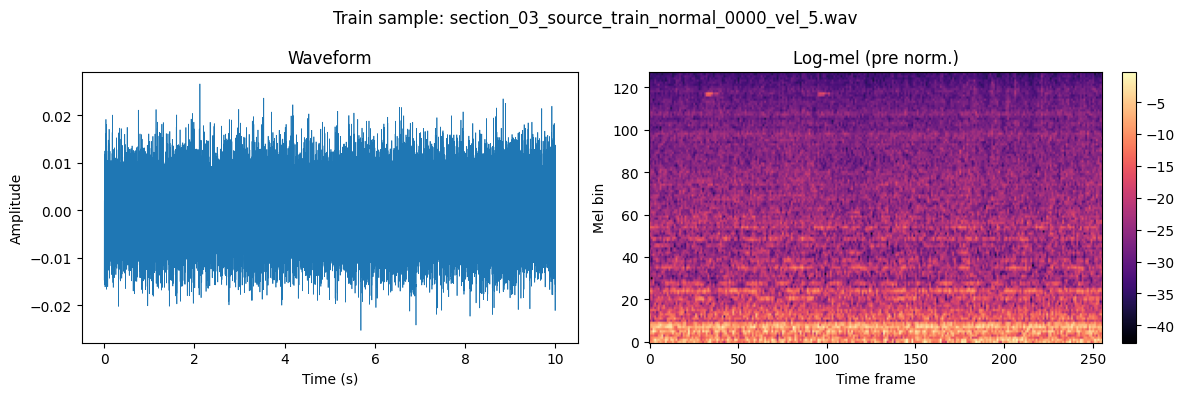

In [5]:
import matplotlib.pyplot as plt
from bearing_asd.data_visualisation import plot_waveform_and_mel

sample = train_wavs[0]
fig = plot_waveform_and_mel(sample, feat, title=f"Train sample: {sample.name}")
plt.show()

## 4. Model — 2D U-Net autoencoder + summary

In [6]:
from bearing_asd.model_unet import build_model, model_summary_text
from bearing_asd.model_summary import print_model_summary

device = torch.device(train_cfg.device)
model = build_model(in_channels=1, base_channels=32).to(device)

dummy = torch.zeros(1, 1, feat.n_mels, feat.mel_time_frames)
print(model_summary_text(model, dummy.to(device)))
print_model_summary(model, input_shape=tuple(dummy.shape), device=str(device))

UNet2DAutoencoder(
  (enc1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_runnin

## 5. DataLoaders — train / validation split (normal only)

In [7]:
train_loader, val_loader = make_train_loaders(
    train_wavs,
    feat,
    batch_size=train_cfg.batch_size,
    val_fraction=train_cfg.val_fraction,
    seed=train_cfg.seed,
    num_workers=train_cfg.num_workers,
)
len(train_loader.dataset), len(val_loader.dataset) if val_loader else 0

(461, 51)

## 6. Training (reconstruction MSE)

In [8]:
from bearing_asd.training import fit

ckpt = PROJECT_ROOT / "results" / "bearing_unet_mel.pt"
result = fit(
    model,
    train_loader,
    val_loader,
    epochs=train_cfg.epochs,
    lr=train_cfg.learning_rate,
    device=device,
    checkpoint_path=ckpt,
)
result["history"], result["checkpoint"]

epochs:   0%|          | 0/20 [00:00<?, ?it/s]

({'train_loss': [0.20673776017966602,
   0.02521908308688446,
   0.013084614130217833,
   0.008988203468718394,
   0.0070669354523437145,
   0.00592036274364804,
   0.004987775821869066,
   0.004324509512730056,
   0.003946726694763709,
   0.003631259953106174,
   0.003471995432661147,
   0.0033197743270683574,
   0.002868953379125631,
   0.0026252062838734683,
   0.002400243495754623,
   0.0022637479945637464,
   0.002224574011999007,
   0.0021322539713589266,
   0.002069690518299372,
   0.00195531425199627],
  'val_loss': [0.3044201351848303,
   0.03518224697487027,
   0.013493361371551073,
   0.008652831391230518,
   0.006739957413325707,
   0.005344497176873333,
   0.004575428671623562,
   0.004574560313759481,
   0.0036236204243465966,
   0.003888409931723978,
   0.0046132393181324005,
   0.005400708547848112,
   0.002968736303349336,
   0.003050327611466249,
   0.0025130375105814604,
   0.0027913625132949915,
   0.003001432861292771,
   0.002426751578847567,
   0.0019363772133182

## 7. Evaluation — labeled dev test (cross-section)

Train sections **03–05** vs. dev test **00–02** is a strict generalization check (different domain-shift scenarios).

In [9]:
from bearing_asd.data_loading import make_dev_manifest_loader
from bearing_asd.evaluation import (
    anomaly_scores,
    evaluate_dev_sections,
    evaluation_report_markdown,
    overall_metrics,
    load_model_weights,
)

if dev_manifest is not None and len(dev_manifest):
    dev_loader = make_dev_manifest_loader(
        dev_manifest, feat, batch_size=train_cfg.batch_size, num_workers=train_cfg.num_workers
    )
    scores_dev = anomaly_scores(model, dev_loader, device)
    idx = dev_manifest.set_index("name")
    scores_dev["section"] = [int(idx.loc[n, "section"]) for n in scores_dev["name"]]
    scores_dev["label"] = [int(idx.loc[n, "label"]) for n in scores_dev["name"]]
    print("Overall:", overall_metrics(scores_dev))
    display(evaluate_dev_sections(scores_dev))
    print(evaluation_report_markdown(scores_dev))
else:
    print("No dev manifest; skipping AUC.")

Overall: {'auc': 0.617488888888889, 'pauc_0.1': 0.07411111111111111}


,section,auc,pauc_0.1,n
0,0,0.7678,0.198,200
1,1,0.6606,0.117,200
2,2,0.3774,0.027,200


### Evaluation metrics (development test)

- **AUC (overall):** 0.6175
- **pAUC @ FPR≤0.1 (overall):** 0.0741
- **N clips:** 600

**Per section (bearing dev 00–02):**

 section    auc  pauc_0.1   n
       0 0.7678     0.198 200
       1 0.6606     0.117 200
       2 0.3774     0.027 200


## 8. Explainability (best checkpoint)

After training, `fit` reloads the **lowest validation loss** weights into `model`. You can also call `load_model_weights(model, ckpt, device)` to load `results/bearing_unet_mel.pt` explicitly.

Plots: input mel, reconstruction, **per-bin squared error** (where the autoencoder disagrees with the input), and **input-gradient saliency** for the clip-wise MSE.

## Summary of Results and Model Performance

The evaluation on the labeled development test set (sections 00-02, which represent a cross-section generalization from training sections 03-05) yielded an overall AUC of **0.6175** and an overall pAUC @ FPR≤0.1 of **0.0741**.

Looking at the performance per section, there's a notable variation:
*   **Section 0**: AUC of 0.7678, pAUC @ FPR≤0.1 of 0.198
*   **Section 1**: AUC of 0.6606, pAUC @ FPR≤0.1 of 0.117
*   **Section 2**: AUC of 0.3774, pAUC @ FPR≤0.1 of 0.027

**Did the model perform well?**

An AUC score closer to 1.0 indicates excellent performance, while 0.5 indicates performance no better than random chance. Given an overall AUC of approximately 0.62, the model's general performance for anomaly detection on this cross-section generalization task is **moderate to poor**. It performs reasonably well on section 0, but its performance drops significantly for section 1 and is notably poor for section 2 (AUC of 0.3774 is worse than random chance, suggesting it might be systematically misclassifying anomalies). This indicates a significant generalization challenge across different bearing sections, potentially due to domain shift or lack of sufficient representative normal data for these specific sections during training.

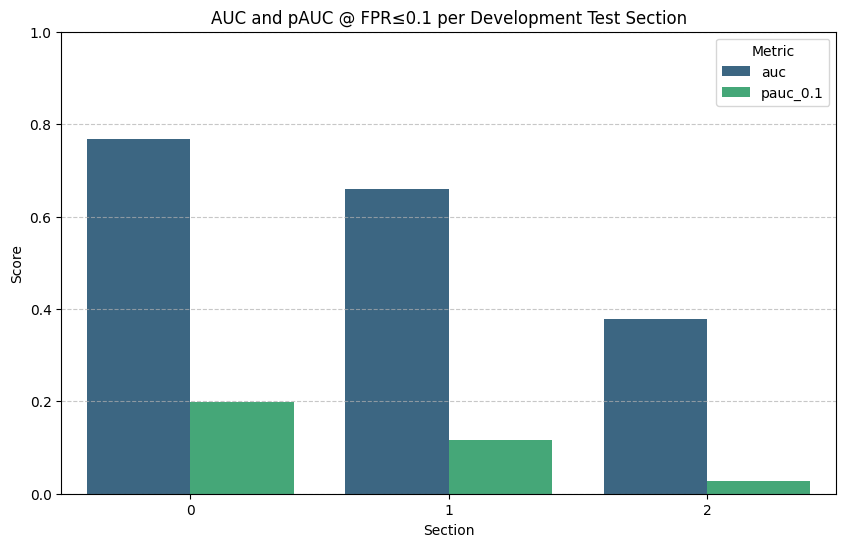

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# The `evaluate_dev_sections` function returns a DataFrame that can be directly used for plotting.
# Assuming `scores_dev` DataFrame is available from previous execution, which it is.
sectional_metrics = evaluate_dev_sections(scores_dev)

# Melt the DataFrame to plot AUC and pAUC on the same chart
melted_metrics = sectional_metrics.melt(id_vars=['section', 'n'], value_vars=['auc', 'pauc_0.1'], var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='section', y='Score', hue='Metric', data=melted_metrics, palette='viridis')
plt.title('AUC and pAUC @ FPR≤0.1 per Development Test Section')
plt.xlabel('Section')
plt.ylabel('Score')
plt.ylim(0, 1.0) # AUC and pAUC are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.show()

### Visualization Interpretation

The bar chart clearly illustrates the performance disparity across different development test sections. While Section 0 shows acceptable AUC and pAUC scores, Section 1's performance is moderate, and Section 2's AUC is significantly below 0.5, indicating that the model struggles to differentiate between normal and anomalous sounds in this specific section. This visualization reinforces the conclusion that the model's generalization capabilities across different sections are limited, and further investigation into the characteristics of Section 2's data might be necessary.

/content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/data/dcase_bearing_dev/bearing/test/section_00_source_test_normal_0000_vel_10.wav clip MSE score: 0.002135094255208969


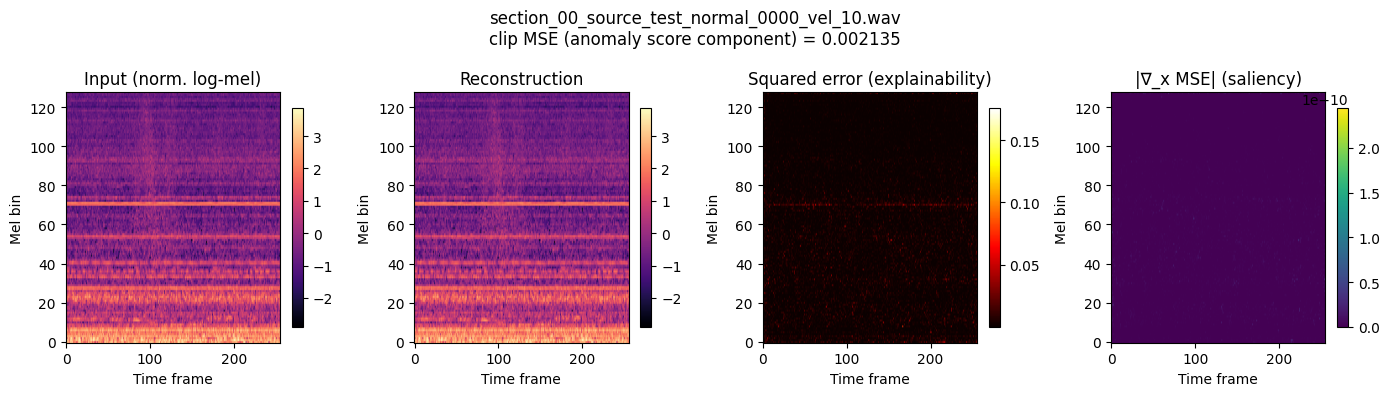

/content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/data/dcase_bearing_dev/bearing/test/section_00_source_test_anomaly_0000_vel_6.wav clip MSE score: 0.0023213974200189114


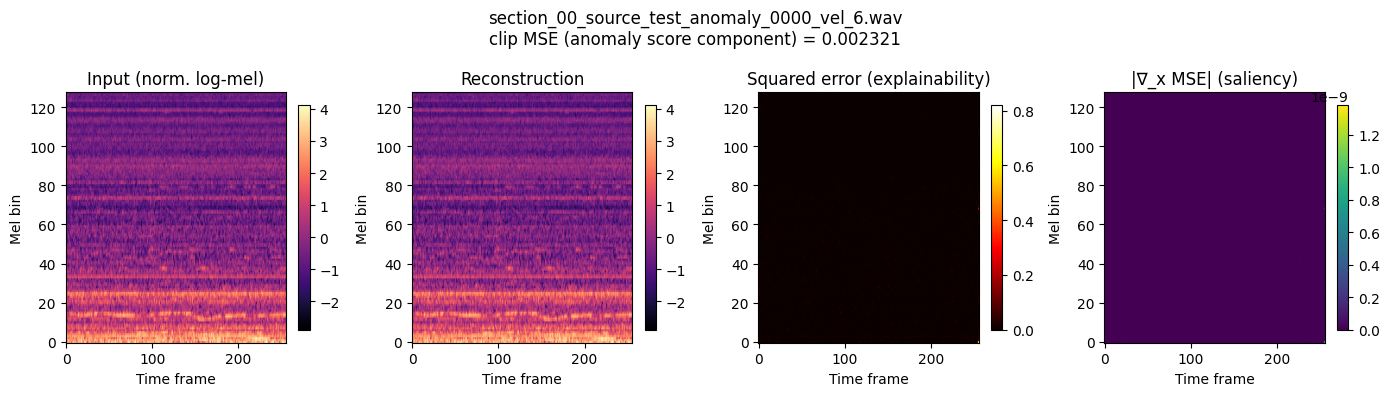

In [10]:
import matplotlib.pyplot as plt
from bearing_asd.explainability import explain_wav_file

# Optional: reload best weights from disk (same as in-memory model after training)
# load_model_weights(model, ckpt, device)

if dev_root is not None:
    test_dir = dev_root / "test"
    sample_normal = next(test_dir.glob("*_test_normal_*.wav"), None)
    sample_anom = next(test_dir.glob("*_test_anomaly_*.wav"), None)
    for p in [sample_normal, sample_anom]:
        if p is None:
            continue
        out = explain_wav_file(model, p, feat, device, with_saliency=True)
        print(out["path"], "clip MSE score:", out["mse"])
        plt.show()
else:
    print("No dev data; skip explainability demo.")

## 9. Evaluation — official-style unlabeled eval clips

Scores are written to `results/anomaly_scores_bearing_eval_test.csv` (filename, score). Without hidden labels, use score ranking / thresholding on validation reconstruction loss.

In [11]:
from bearing_asd.data_loading import make_simple_loader
from bearing_asd.evaluation import anomaly_scores, save_scores_csv

eval_loader = make_simple_loader(
    eval_test_wavs,
    feat,
    batch_size=train_cfg.batch_size,
    num_workers=train_cfg.num_workers,
    shuffle=False,
)
scores_eval = anomaly_scores(model, eval_loader, device)
out_csv = PROJECT_ROOT / "results" / "anomaly_scores_bearing_eval_test.csv"
save_scores_csv(scores_eval, out_csv)
scores_eval.head(), out_csv

(                                                path                 name  \
 0  /content/drive/MyDrive/Colab Notebooks/Unsuper...  section_03_0000.wav   
 1  /content/drive/MyDrive/Colab Notebooks/Unsuper...  section_03_0001.wav   
 2  /content/drive/MyDrive/Colab Notebooks/Unsuper...  section_03_0002.wav   
 3  /content/drive/MyDrive/Colab Notebooks/Unsuper...  section_03_0003.wav   
 4  /content/drive/MyDrive/Colab Notebooks/Unsuper...  section_03_0004.wav   
 
       score  
 0  0.002661  
 1  0.002152  
 2  0.001509  
 3  0.002479  
 4  0.001812  ,
 PosixPath('/content/drive/MyDrive/Colab Notebooks/Unsupervised_anomalous_sound/results/anomaly_scores_bearing_eval_test.csv'))